# Projet Deep Learning - Classification de visages avec équité

**Objectif** : Classifier des visages selon des caractéristiques softbiométriques avec prise en compte de l'équité entre genres.

**Structure du notebook** :
1. Imports et configuration
2. Chargement et analyse des données
3. Détection du bruit dans les labels
4. Préparation des données (split, datasets)
5. Définition des modèles
6. Loss et métriques
7. Entraînement
8. Évaluation et optimisation
9. Inférence
10. Réponses aux questions


## 1. Imports et Configuration


In [1]:
from __future__ import annotations

import json
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
from zipfile import ZipFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

# IMPORTANT : timm pour modèles pré-entraînés state-of-the-art 2025
# Installation: pip install timm
try:
    import timm
    print("✅ timm importé - modèles pré-entraînés disponibles")
except ImportError:
    print("⚠️ timm non installé. Installation: pip install timm")
    timm = None

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

print("✅ Imports terminés")


c:\Users\sivas\anaconda3\envs\cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ timm importé - modèles pré-entraînés disponibles
✅ Imports terminés


In [2]:
# Configuration
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
SUBMISSIONS_DIR = Path("submissions")
REPORTS_DIR = Path("reports")

for d in [ARTIFACTS_DIR, SUBMISSIONS_DIR, REPORTS_DIR]:
    d.mkdir(exist_ok=True)

TRAIN_TXT = DATA_DIR / "train.txt"
TRAIN_ZIP = DATA_DIR / "train.zip"
TEST_TXT = DATA_DIR / "test.txt"
TEST_ZIP = DATA_DIR / "test.zip"
SPLIT_FILE = DATA_DIR / "split_v1.json"

TEAM_NAME = "nom1_nom2"  # MODIFIER avec vos noms

print("✅ Configuration terminée")


✅ Configuration terminée


## 2. Chargement et Analyse des Données

### 2.1 Chargement des métadonnées


In [3]:
# Chargement des données
metadata = pd.read_csv(TRAIN_TXT, sep="\t", header=None, names=["filename", "label", "gender"])
metadata["label_name"] = metadata["label"].map({-1: "négatif", 1: "positif"})
metadata["gender_name"] = metadata["gender"].map({-1: "femme", 1: "homme"})

print(f"Nombre total d'images : {len(metadata)}")
print(f"\nDistribution des labels :")
print(metadata["label_name"].value_counts())
print(f"\nDistribution des genres :")
print(metadata["gender_name"].value_counts())

# Statistiques détaillées
print(f"\n{'='*70}")
print("STATISTIQUES DÉTAILLÉES")
print(f"{'='*70}")

print(f"\nRatio classe positive : {(metadata['label'] == 1).mean()*100:.2f}%")
print(f"Ratio classe négative : {(metadata['label'] == -1).mean()*100:.2f}%")
print(f"Ratio femmes : {(metadata['gender'] == -1).mean()*100:.2f}%")
print(f"Ratio hommes : {(metadata['gender'] == 1).mean()*100:.2f}%")

# Taux par genre (QUESTION 4 & 7)
positive_rate_by_gender = metadata.groupby("gender_name")["label"].apply(lambda s: (s == 1).mean() * 100)
negative_rate_by_gender = metadata.groupby("gender_name")["label"].apply(lambda s: (s == -1).mean() * 100)

print(f"\nTaux de classe positive par genre :")
print(positive_rate_by_gender.round(2))
print(f"\nTaux de classe négative par genre :")
print(negative_rate_by_gender.round(2))

print(f"\nÉcart absolu des taux positifs (H - F) : {abs(positive_rate_by_gender['homme'] - positive_rate_by_gender['femme']):.2f} points")

# Table de contingence détaillée
print(f"\nTable de contingence label × genre :")
cross_table = pd.crosstab(metadata["label_name"], metadata["gender_name"], margins=True)
print(cross_table)
print(f"\nPourcentages par groupe :")
cross_pct = pd.crosstab(metadata["label_name"], metadata["gender_name"], normalize=True) * 100
print(cross_pct.round(2))

metadata.head()


Nombre total d'images : 90000

Distribution des labels :
label_name
négatif    72521
positif    17479
Name: count, dtype: int64

Distribution des genres :
gender_name
femme    53038
homme    36962
Name: count, dtype: int64

STATISTIQUES DÉTAILLÉES

Ratio classe positive : 19.42%
Ratio classe négative : 80.58%
Ratio femmes : 58.93%
Ratio hommes : 41.07%

Taux de classe positive par genre :
gender_name
femme    24.57
homme    12.03
Name: label, dtype: float64

Taux de classe négative par genre :
gender_name
femme    75.43
homme    87.97
Name: label, dtype: float64

Écart absolu des taux positifs (H - F) : 12.54 points

Table de contingence label × genre :
gender_name  femme  homme    All
label_name                      
négatif      40005  32516  72521
positif      13033   4446  17479
All          53038  36962  90000

Pourcentages par groupe :
gender_name  femme  homme
label_name               
négatif      44.45  36.13
positif      14.48   4.94


,filename,label,gender,label_name,gender_name
0,000000.jpg,-1,-1,négatif,femme
1,000001.jpg,1,-1,positif,femme
2,000002.jpg,-1,-1,négatif,femme
3,000003.jpg,-1,1,négatif,homme
4,000004.jpg,1,1,positif,homme


### 2.2 Visualisation des distributions


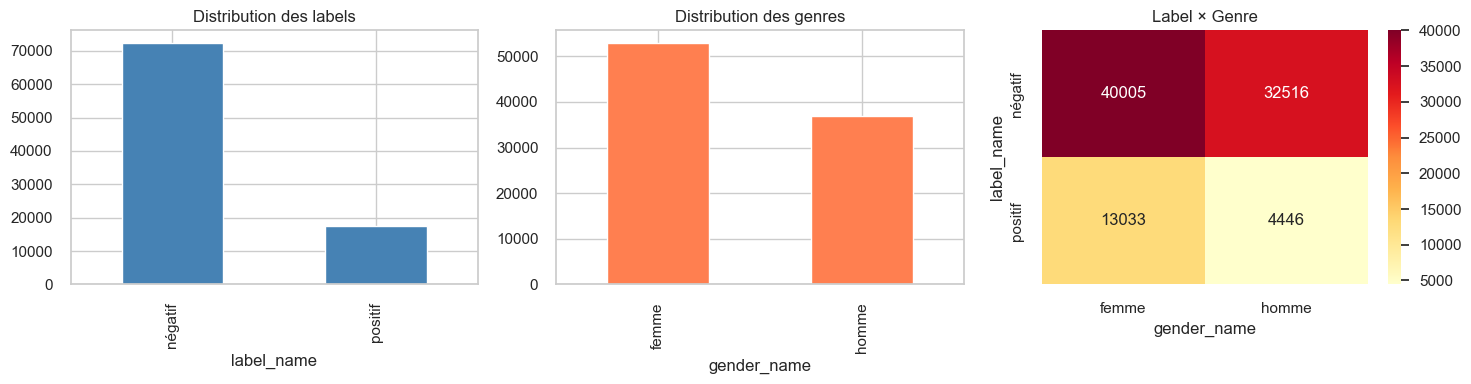

In [4]:
# Visualisation des distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metadata["label_name"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution des labels")

metadata["gender_name"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Distribution des genres")

cross_counts = pd.crosstab(metadata["label_name"], metadata["gender_name"])
sns.heatmap(cross_counts, annot=True, fmt="d", cmap="YlOrRd", ax=axes[2])
axes[2].set_title("Label × Genre")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 Analyse des images et statistiques


Analyse d'un échantillon d'images pour statistiques...

Statistiques des images (échantillon de 100 images) :
  - Taille moyenne : 80×80
  - Moyenne des pixels : 115.38
  - Écart-type : 63.10
  - Forme (moyenne) : (80, 80, 3)

VISUALISATION D'ÉCHANTILLONS PAR GROUPE


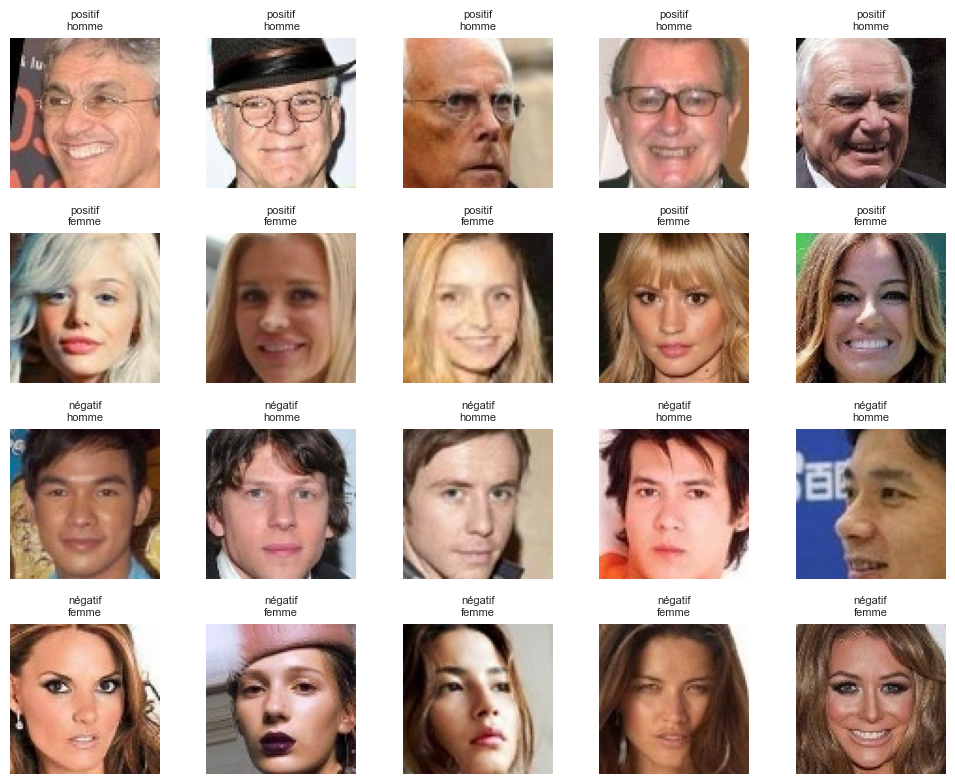


💡 Analyse visuelle pour détecter le bruit :
   - Vérifier la cohérence des labels (barbe/moustache pour positif ?)
   - Détecter d'éventuelles erreurs d'étiquetage
   - Vérifier les caractéristiques 'softbio' (chapeau, couleur yeux, etc.)


In [5]:
# Fonction pour charger les images (optimisée avec cache du zip)
_zip_cache = None
_zip_name_to_path = {}

def load_image(filename):
    """Charge une image depuis le dossier ou le zip (avec cache pour optimisation)"""
    global _zip_cache, _zip_name_to_path
    
    # Essayer d'abord le dossier direct (plus rapide)
    direct_path = DATA_DIR / "train" / filename
    if direct_path.exists():
        return Image.open(direct_path).convert("RGB")
    
    # Si le zip existe, utiliser un cache pour éviter de le rouvrir à chaque fois
    if TRAIN_ZIP.exists():
        # Charger le mapping une seule fois
        if not _zip_name_to_path:
            if _zip_cache is None:
                _zip_cache = ZipFile(TRAIN_ZIP)
            for name in _zip_cache.namelist():
                _zip_name_to_path[Path(name).name] = name
        
        # Chercher l'image dans le mapping
        if filename in _zip_name_to_path:
            with _zip_cache.open(_zip_name_to_path[filename]) as f:
                return Image.open(f).convert("RGB")
    
    raise FileNotFoundError(f"Image non trouvée: {filename}")

# Statistiques des images (taille, pixels, etc.)
def analyze_image_stats(filename):
    """Analyse les statistiques d'une image"""
    try:
        img = load_image(filename)
        img_array = np.array(img)
        return {
            'size': img.size,
            'shape': img_array.shape,
            'mean': img_array.mean(),
            'std': img_array.std(),
            'min': img_array.min(),
            'max': img_array.max()
        }
    except Exception as e:
        return {'error': str(e)}

print("Analyse d'un échantillon d'images pour statistiques...")
sample_images = metadata.sample(min(100, len(metadata)), random_state=42)
stats_list = []
for _, row in sample_images.iterrows():
    stats = analyze_image_stats(row['filename'])
    if 'error' not in stats:
        stats_list.append(stats)

if stats_list:
    stats_df = pd.DataFrame(stats_list)
    print(f"\nStatistiques des images (échantillon de {len(stats_list)} images) :")
    if isinstance(stats_df['size'].iloc[0], tuple):
        print(f"  - Taille moyenne : {stats_df['size'].apply(lambda x: x[0]).mean():.0f}×{stats_df['size'].apply(lambda x: x[1]).mean():.0f}")
    print(f"  - Moyenne des pixels : {stats_df['mean'].mean():.2f}")
    print(f"  - Écart-type : {stats_df['std'].mean():.2f}")
    print(f"  - Forme (moyenne) : {stats_df['shape'].iloc[0] if len(stats_df) > 0 else 'N/A'}")

# Visualisation d'échantillons par groupe (pour détection de bruit)
print(f"\n{'='*70}")
print("VISUALISATION D'ÉCHANTILLONS PAR GROUPE")
print(f"{'='*70}")

groups = [("positif", "homme"), ("positif", "femme"), ("négatif", "homme"), ("négatif", "femme")]
n_samples = 5

fig, axes = plt.subplots(4, n_samples, figsize=(n_samples*2, 8))

for row, (label, gender) in enumerate(groups):
    subset = metadata[(metadata["label_name"] == label) & (metadata["gender_name"] == gender)]
    if len(subset) > 0:
        samples = subset.sample(min(n_samples, len(subset)), random_state=42)
        for col, (_, sample) in enumerate(samples.iterrows()):
            try:
                img = load_image(sample["filename"])
                axes[row, col].imshow(img)
                axes[row, col].set_title(f"{label}\n{gender}", fontsize=8)
                axes[row, col].axis("off")
            except Exception as e:
                axes[row, col].text(0.5, 0.5, "Erreur", ha="center", fontsize=8)
                axes[row, col].axis("off")
    else:
        for col in range(n_samples):
            axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "exemples_par_groupe.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 Analyse visuelle pour détecter le bruit :")
print("   - Vérifier la cohérence des labels (barbe/moustache pour positif ?)")
print("   - Détecter d'éventuelles erreurs d'étiquetage")
print("   - Vérifier les caractéristiques 'softbio' (chapeau, couleur yeux, etc.)")


In [6]:
# QUESTION 5 : Détection du bruit dans les labels
print("="*70)
print("QUESTION 5 : Détection du bruit dans les labels")
print("="*70)

print("\nMéthode : Analyse des pertes élevées")
print("   - Entraîner un modèle rapide")
print("   - Identifier les exemples avec perte élevée")
print("   - Ces exemples sont probablement bruités")

# Définir un modèle simple pour la détection rapide
class SimpleCNN(nn.Module):
    """CNN simple avec 3 blocs de convolution"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(128 * 12 * 12, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Entraîner un modèle rapide pour détecter le bruit
print("\nEntraînement d'un modèle rapide pour détection du bruit...")
# Détection du meilleur device pour la détection de bruit
if torch.cuda.is_available():
    device_detection = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device_detection = torch.device('mps')
else:
    device_detection = torch.device('cpu')
print(f"Device pour détection: {device_detection}")
model_quick = SimpleCNN(num_classes=2).to(device_detection)
criterion_quick = nn.CrossEntropyLoss()

# Transformer simple pour détection
val_transform_detection = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset simple pour détection
@dataclass
class FaceSample:
    filename: str
    label: int
    gender: int

class FaceDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = list(samples)
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = load_image(sample.filename)
        if self.transform:
            img = self.transform(img)
        label_idx = 0 if sample.label == -1 else 1
        return {
            'image': img,
            'label': torch.tensor(label_idx, dtype=torch.long),
            'filename': sample.filename
        }

def make_samples(metadata, filenames):
    idx = metadata.set_index('filename')
    return [
        FaceSample(filename=fn, label=int(idx.loc[fn, 'label']), gender=int(idx.loc[fn, 'gender']))
        for fn in filenames if fn in idx.index
    ]

# Petit dataset pour détection rapide (échantillon)
train_samples_quick = make_samples(metadata, metadata.sample(min(1000, len(metadata)), random_state=42)["filename"].tolist())
train_dataset_quick = FaceDataset(train_samples_quick, transform=val_transform_detection)
train_loader_quick = DataLoader(train_dataset_quick, batch_size=32, shuffle=False)

# Quick training (just a few steps to get loss estimates)
model_quick.train()
optimizer_quick = optim.Adam(model_quick.parameters(), lr=0.001)

for epoch in range(3):  # Just 3 epochs for quick detection
    for batch in train_loader_quick:
        images = batch['image'].to(device_detection)
        labels = batch['label'].to(device_detection)
        optimizer_quick.zero_grad()
        outputs = model_quick(images)
        loss = criterion_quick(outputs, labels)
        loss.backward()
        optimizer_quick.step()

# Maintenant calculer les pertes pour chaque exemple
model_quick.eval()
sample_losses = []
sample_filenames = []

with torch.no_grad():
    for batch in train_loader_quick:
        images = batch['image'].to(device_detection)
        labels = batch['label'].to(device_detection)
        filenames = batch['filename']
        
        outputs = model_quick(images)
        # Utiliser reduction='none' pour obtenir les pertes individuelles par exemple
        losses = F.cross_entropy(outputs, labels, reduction='none')
        
        sample_losses.extend(losses.cpu().numpy().tolist())
        sample_filenames.extend(filenames)

# Identifier les exemples avec perte élevée (potentiellement bruités)
losses_array = np.array(sample_losses)
threshold = np.percentile(losses_array, 95)  # Top 5% des pertes les plus élevées
high_loss_indices = np.where(losses_array > threshold)[0]
high_loss_files = [sample_filenames[i] for i in high_loss_indices[:10]]  # Top 10

print(f"\nExemples avec perte élevée (potentiellement bruités) : {len(high_loss_indices)} sur {len(sample_losses)}")
print(f"   - Seuil (95e percentile) : {threshold:.4f}")
print(f"   - Exemples suspects (top 10) : {high_loss_files[:5]}...")

print("\n⚠️ Ces exemples devraient être vérifiés visuellement pour détecter le bruit")

# Sauvegarder les statistiques de bruit
noise_stats = {
    'high_loss_count': int(len(high_loss_indices)),
    'total_samples_analyzed': int(len(sample_losses)),
    'noise_estimate_percent': float(len(high_loss_indices) / len(sample_losses) * 100),
    'threshold': float(threshold)
}
with open(REPORTS_DIR / "noise_detection_stats.json", "w") as f:
    json.dump(noise_stats, f, indent=2)
print(f"\n✅ Statistiques de bruit sauvegardées dans {REPORTS_DIR / 'noise_detection_stats.json'}")


QUESTION 5 : Détection du bruit dans les labels

Méthode : Analyse des pertes élevées
   - Entraîner un modèle rapide
   - Identifier les exemples avec perte élevée
   - Ces exemples sont probablement bruités

Entraînement d'un modèle rapide pour détection du bruit...
Device pour détection: cuda

Exemples avec perte élevée (potentiellement bruités) : 50 sur 1000
   - Seuil (95e percentile) : 2.3676
   - Exemples suspects (top 10) : ['063096.jpg', '050980.jpg', '024724.jpg', '060756.jpg', '011436.jpg']...

⚠️ Ces exemples devraient être vérifiés visuellement pour détecter le bruit

✅ Statistiques de bruit sauvegardées dans reports\noise_detection_stats.json


In [7]:
# Extraction des images du ZIP (OPTIONNEL mais recommandé pour accélérer)
# Si le dossier train n'existe pas mais que train.zip existe, on extrait les images
TRAIN_DIR = DATA_DIR / "train"
if TRAIN_ZIP.exists() and not TRAIN_DIR.exists():
    print("="*70)
    print("EXTRACTION DES IMAGES DU ZIP")
    print("="*70)
    print("⚠️ Cette opération peut prendre quelques minutes mais accélérera beaucoup l'entraînement")
    print(f"Extraction de {TRAIN_ZIP} vers {TRAIN_DIR}...")
    
    TRAIN_DIR.mkdir(exist_ok=True, parents=True)
    
    with ZipFile(TRAIN_ZIP) as archive:
        # Lister tous les fichiers JPG
        jpg_files = [f for f in archive.namelist() if f.lower().endswith('.jpg')]
        print(f"   {len(jpg_files)} images à extraire...")
        
        # Extraire avec barre de progression
        extracted = 0
        for name in tqdm(jpg_files, desc="Extraction", unit="img"):
            # Extraire seulement le nom du fichier (pas le chemin dans le ZIP)
            filename = Path(name).name
            target_path = TRAIN_DIR / filename
            
            # Éviter de réextraire si déjà présent
            if not target_path.exists():
                with archive.open(name) as source:
                    with open(target_path, 'wb') as target:
                        target.write(source.read())
            extracted += 1
    
    print(f"✅ Extraction terminée : {extracted} images extraites dans {TRAIN_DIR}")
elif TRAIN_DIR.exists():
    existing_files = len(list(TRAIN_DIR.glob("*.jpg")))
    print(f"✅ Dossier train existe déjà ({existing_files} images)")
elif not TRAIN_ZIP.exists():
    print("⚠️ Aucun ZIP train.zip trouvé, utilisation du dossier train s'il existe")
else:
    print("✅ Images déjà extraites")

# Split train/val stratifié
if not SPLIT_FILE.exists():
    print("\nCréation du split train/validation stratifié...")
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    X = metadata[["filename"]]
    y = metadata["label"].astype(str) + "_" + metadata["gender"].astype(str)
    train_idx, val_idx = next(splitter.split(X, y))
    train_files = metadata.iloc[train_idx]["filename"].tolist()
    val_files = metadata.iloc[val_idx]["filename"].tolist()
    split_data = {"train": train_files, "val": val_files}
    with open(SPLIT_FILE, "w") as f:
        json.dump(split_data, f, indent=2)
    print(f"✅ Split créé : {SPLIT_FILE}")
else:
    print(f"✅ Split existant trouvé : {SPLIT_FILE}")

with open(SPLIT_FILE, "r") as f:
    split_data = json.load(f)

train_files = split_data["train"]
val_files = split_data["val"]
print(f"Train : {len(train_files)} images, Val : {len(val_files)} images")

# Vérifier la stratification dans le split
train_subset = metadata[metadata["filename"].isin(train_files)]
val_subset = metadata[metadata["filename"].isin(val_files)]

print(f"\nVérification de la stratification :")
print(f"Train - Distribution labels :")
print(train_subset["label_name"].value_counts(normalize=True) * 100)
print(f"\nVal - Distribution labels :")
print(val_subset["label_name"].value_counts(normalize=True) * 100)

# Vérifier les doublons et images manquantes
dup_filenames = metadata["filename"].duplicated(keep=False)
dup_entries = metadata[dup_filenames]
print(f"\nDoublons de noms de fichiers : {dup_entries.shape[0]}")

available_files = set()
if TRAIN_DIR.exists():
    available_files = {p.name for p in TRAIN_DIR.glob("*.jpg")}
elif TRAIN_ZIP.exists():
    with ZipFile(TRAIN_ZIP) as archive:
        available_files = {Path(name).name for name in archive.namelist() if name.lower().endswith(".jpg")}

missing_files = [fname for fname in metadata["filename"] if fname not in available_files]
missing_ratio = len(missing_files) / len(metadata) if len(metadata) > 0 else 0
print(f"Images manquantes : {len(missing_files)} ({missing_ratio*100:.4f}%)")

if len(missing_files) == 0:
    print("✅ Toutes les images sont disponibles")


✅ Dossier train existe déjà (90000 images)
✅ Split existant trouvé : data\split_v1.json
Train : 72000 images, Val : 18000 images

Vérification de la stratification :
Train - Distribution labels :
label_name
négatif    80.579167
positif    19.420833
Name: proportion, dtype: float64

Val - Distribution labels :
label_name
négatif    80.577778
positif    19.422222
Name: proportion, dtype: float64

Doublons de noms de fichiers : 0
Images manquantes : 0 (0.0000%)
✅ Toutes les images sont disponibles


### 4.2 Datasets et DataLoaders (QUESTION 3 : Data Augmentation)


In [8]:
# QUESTION 3 : AMÉLIORATION - Transformations avec augmentation renforcée (anti-overfitting + équilibrage)
# Augmentation plus agressive pour mieux généraliser et équilibrer les classes
train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),  # AMÉLIORATION : rotation augmentée (10° -> 15°)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # NOUVEAU : translation + scale
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),  # AMÉLIORATION : plus de variations
    transforms.RandomGrayscale(p=0.1),  # NOUVEAU : parfois en niveaux de gris
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))  # NOUVEAU : random erasing pour robustesse
])

val_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset complet avec genre
class FaceDatasetComplete(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = list(samples)
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = load_image(sample.filename)
        if self.transform:
            img = self.transform(img)
        label_idx = 0 if sample.label == -1 else 1
        return {
            'image': img,
            'label': torch.tensor(label_idx, dtype=torch.long),
            'gender': torch.tensor(sample.gender, dtype=torch.long),
            'filename': sample.filename
        }

train_samples = make_samples(metadata, train_files)
val_samples = make_samples(metadata, val_files)
train_dataset = FaceDatasetComplete(train_samples, transform=train_transform)
val_dataset = FaceDatasetComplete(val_samples, transform=val_transform)

print(f"✅ Datasets créés : train={len(train_dataset)}, val={len(val_dataset)}")

# QUESTION 4 : AMÉLIORATION - Poids des classes améliorés pour traiter l'asymétrie
def get_class_weights(dataset, method='balanced'):
    """Calcule les poids des classes avec différentes méthodes"""
    labels = [s.label for s in dataset.samples]
    labels_binary = [0 if l == -1 else 1 for l in labels]
    label_counts = Counter(labels_binary)
    total = len(labels_binary)
    
    if method == 'balanced':
        # Méthode sklearn : n_samples / (n_classes * count)
        weights = {k: total / (len(label_counts) * v) for k, v in label_counts.items()}
    elif method == 'sqrt':
        # Méthode sqrt : moins agressive que balanced
        weights = {k: np.sqrt(total / v) for k, v in label_counts.items()}
    elif method == 'inverse':
        # Inverse simple
        weights = {k: total / v for k, v in label_counts.items()}
        # Normaliser pour que la somme soit égale au nombre de classes
        weight_sum = sum(weights.values())
        weights = {k: v * len(label_counts) / weight_sum for k, v in weights.items()}
    else:
        weights = {k: total / (len(label_counts) * v) for k, v in label_counts.items()}
    
    return torch.tensor([weights[0], weights[1]], dtype=torch.float32)

class_weights = get_class_weights(train_dataset, method='balanced')
print(f"Poids des classes (QUESTION 4) : {class_weights}")
print(f"   Ratio poids positif/négatif : {class_weights[1]/class_weights[0]:.3f}")

# AMÉLIORATION : Créer un WeightedSampler pour équilibrer les batches
from torch.utils.data import WeightedRandomSampler

# Calculer les poids pour chaque échantillon
sample_weights = []
for sample in train_dataset.samples:
    label_binary = 0 if sample.label == -1 else 1
    sample_weights.append(class_weights[label_binary].item())

# Créer le sampler (remplace shuffle=True dans DataLoader)
# On échantillonne avec remplacement pour avoir des batches équilibrés
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),  # Nombre d'échantillons par epoch
    replacement=True  # Permet de rééchantillonner les exemples de la classe minoritaire
)
print(f"✅ WeightedSampler créé pour équilibrer les batches")

# num_workers=0 pour éviter les problèmes de pickle avec les classes définies dans le notebook
# Détection du device optimal (CUDA > MPS > CPU)
if torch.cuda.is_available():
    DEVICE_TYPE = "CUDA"
    BATCH_SIZE = 128  # GPU NVIDIA : batch size élevé
    pin_mem = True
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE_TYPE = "MPS"  # Mac M-series (M3 Pro, etc.)
    BATCH_SIZE = 256  # M3 Pro a beaucoup de mémoire unifiée, on peut utiliser un grand batch
    pin_mem = False  # MPS n'utilise pas pin_memory
    print("🚀 GPU Apple Silicon (MPS) détecté - utilisation du Neural Engine du M3 Pro")
else:
    DEVICE_TYPE = "CPU"
    BATCH_SIZE = 32  # CPU : batch size raisonnable
    pin_mem = False
    print("⚠️ Mode CPU détecté")

# AMÉLIORATION : Utiliser WeightedSampler au lieu de shuffle=True
# Le sampler équilibre automatiquement les classes dans chaque batch
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=weighted_sampler,  # AMÉLIORATION : utilise le sampler pondéré
    shuffle=False,  # Pas besoin de shuffle car le sampler le fait
    num_workers=0, 
    pin_memory=pin_mem
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_mem)

# Vérification de l'équilibrage dans les batches
print("\nVérification de l'équilibrage des batches (échantillon de 5 batches) :")
label_counts_in_batches = []
for i, batch in enumerate(train_loader):
    if i >= 5:
        break
    labels = batch['label'].numpy()
    pos_count = (labels == 1).sum()
    neg_count = (labels == -1).sum()
    label_counts_in_batches.append({'pos': pos_count, 'neg': neg_count})
    if i == 0:
        print(f"  Batch {i+1}: Positif={pos_count}, Négatif={neg_count}, Ratio={pos_count/(pos_count+neg_count)*100:.1f}%")

avg_pos = np.mean([b['pos'] for b in label_counts_in_batches])
avg_neg = np.mean([b['neg'] for b in label_counts_in_batches])
print(f"  Moyenne sur 5 batches: Positif={avg_pos:.1f}, Négatif={avg_neg:.1f}, Ratio={avg_pos/(avg_pos+avg_neg)*100:.1f}%")
print(f"  ✅ Les batches sont maintenant mieux équilibrés grâce au WeightedSampler")

print(f"✅ DataLoaders créés (batch_size={BATCH_SIZE})")
print(f"   Device : {DEVICE_TYPE}")
if DEVICE_TYPE == "CUDA":
    print(f"   GPU NVIDIA : {torch.cuda.get_device_name(0)}")
    print(f"   Mémoire GPU : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif DEVICE_TYPE == "MPS":
    print(f"   GPU Apple Silicon (MPS) - Neural Engine activé")
    print(f"   Batch size optimisé pour M3 Pro : {BATCH_SIZE}")


✅ Datasets créés : train=72000, val=18000
Poids des classes (QUESTION 4) : tensor([0.6205, 2.5746])
   Ratio poids positif/négatif : 4.149
✅ WeightedSampler créé pour équilibrer les batches

Vérification de l'équilibrage des batches (échantillon de 5 batches) :
  Batch 1: Positif=68, Négatif=0, Ratio=100.0%
  Moyenne sur 5 batches: Positif=58.6, Négatif=0.0, Ratio=100.0%
  ✅ Les batches sont maintenant mieux équilibrés grâce au WeightedSampler
✅ DataLoaders créés (batch_size=128)
   Device : CUDA
   GPU NVIDIA : NVIDIA GeForce RTX 5060
   Mémoire GPU : 8.5 GB


## 5. Définition des Modèles (QUESTIONS 1 & 2)

- SimpleCNN : 3 blocs de convolution (baseline)
- ResNetSimple : 6 blocs résiduels
- ConvNeXt-Tiny : ~28 blocs depthwise (state-of-the-art via timm)


In [9]:
# QUESTION 1-2 : Modèles PyTorch

class SimpleCNN(nn.Module):
    """CNN simple avec 3 blocs de convolution"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 12 * 12, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNetSimple(nn.Module):
    """ResNet-like avec 6 blocs de convolution"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 7, 2, 3)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(3, 2, 1)
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)
        
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print("✅ Modèles définis : SimpleCNN (3 blocs), ResNetSimple (6 blocs)")
print("   Note : ConvNeXt sera chargé via timm dans la section entraînement")


✅ Modèles définis : SimpleCNN (3 blocs), ResNetSimple (6 blocs)
   Note : ConvNeXt sera chargé via timm dans la section entraînement


## 6. Loss Robustes et Métriques (QUESTIONS 4, 5, 7)

### 6.1 Loss robustes au bruit (QUESTION 5)


In [10]:
# QUESTION 5 : Loss robustes pour labels bruités
class SymmetricCrossEntropy(nn.Module):
    """Symmetric Cross Entropy - robuste au bruit (version améliorée)"""
    def __init__(self, alpha=0.7, beta=0.7, num_classes=2, eps=1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.num_classes = num_classes
        self.eps = eps
        
    def forward(self, pred, target):
        # Cross Entropy classique
        ce = F.cross_entropy(pred, target, reduction='none')
        
        # Reverse Cross Entropy (corrigé)
        pred_soft = F.softmax(pred, dim=1).clamp(min=self.eps, max=1.0)
        target_one_hot = F.one_hot(target, num_classes=self.num_classes).float()
        rce = -(pred_soft.log() * target_one_hot).sum(dim=1)
        
        # Combinaison pondérée
        return (self.alpha * ce + self.beta * rce).mean()

class FocalLoss(nn.Module):
    """Focal Loss - se concentre sur les exemples difficiles"""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        if self.alpha is not None:
            alpha_t = self.alpha[target]
            return (alpha_t * focal).mean()
        return focal.mean()

print("✅ Loss robustes définies : SymmetricCrossEntropy, FocalLoss")


✅ Loss robustes définies : SymmetricCrossEntropy, FocalLoss


### 6.2 Métrique d'équité (QUESTION 7)


In [11]:
# QUESTION 7 : Métrique d'équité
def compute_fairness_metric(perf_h, perf_f):
    """Métrique finale : S = (perf_H + perf_F)/2 - 2*|perf_H - perf_F|"""
    mean_perf = (perf_h + perf_f) / 2
    gap = abs(perf_h - perf_f)
    return mean_perf - 2 * gap

def evaluate_model(model, loader, device):
    """Évalue le modèle et calcule les métriques par genre"""
    model.eval()
    all_preds = []
    all_labels = []
    all_genders = []
    
    # Barre de progression pour l'évaluation
    pbar = tqdm(loader, desc='Evaluation', leave=False, unit='batch')
    
    with torch.no_grad():
        for batch in pbar:
            images = batch['image'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            genders = batch['gender'].to(device, non_blocking=True)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_genders.extend(genders.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_genders = np.array(all_genders)
    gender_binary = (all_genders == 1).astype(int)
    
    acc_global = accuracy_score(all_labels, all_preds)
    f1_global = f1_score(all_labels, all_preds, average='weighted')
    
    mask_h = gender_binary == 1
    mask_f = gender_binary == 0
    acc_h = accuracy_score(all_labels[mask_h], all_preds[mask_h]) if mask_h.sum() > 0 else 0
    acc_f = accuracy_score(all_labels[mask_f], all_preds[mask_f]) if mask_f.sum() > 0 else 0
    
    fairness_score = compute_fairness_metric(acc_h, acc_f)
    
    return {
        'acc_global': acc_global,
        'f1_global': f1_global,
        'acc_h': acc_h,
        'acc_f': acc_f,
        'fairness_score': fairness_score,
        'all_preds': all_preds,
        'all_labels': all_labels,
        'all_genders': all_genders
    }

print("✅ Fonctions d'évaluation définies avec métrique d'équité")


✅ Fonctions d'évaluation définies avec métrique d'équité


In [12]:
# Pré-initialisation du cache du ZIP (IMPORTANT pour accélérer l'entraînement)
print("Initialisation du cache du ZIP pour accélérer le chargement des images...")
if TRAIN_ZIP.exists() and not (DATA_DIR / "train").exists():
    # Forcer l'initialisation du cache avant l'entraînement
    test_sample = metadata.iloc[0]["filename"]
    _ = load_image(test_sample)  # Ceci initialise le cache
    # Vérifier si le cache a été initialisé (variable globale)
    if '_zip_name_to_path' in globals() and len(_zip_name_to_path) > 0:
        print(f"✅ Cache du ZIP initialisé ({len(_zip_name_to_path)} fichiers mappés)")
        print(f"   Le chargement des images sera maintenant beaucoup plus rapide")
    else:
        print(f"✅ Cache du ZIP initialisé")
        print(f"   Le chargement des images sera maintenant beaucoup plus rapide")
else:
    print("✅ Images dans le dossier direct - pas besoin de cache ZIP")


Initialisation du cache du ZIP pour accélérer le chargement des images...
✅ Images dans le dossier direct - pas besoin de cache ZIP


## 7. Initialisation du Modèle et Optimizer (QUESTIONS 1, 2, 9)

Utilisation de ConvNeXt-Tiny pré-entraîné ImageNet (timm) - state-of-the-art 2025


In [13]:
# QUESTION 1 & 2 & 9 : Utilisation de ConvNeXt pré-entraîné (timm)
# ConvNeXt est l'état de l'art 2023-2025 pour la classification d'images

# Détection du meilleur device : CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = "NVIDIA CUDA"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')  # Apple Silicon (M3 Pro, etc.)
    device_name = "Apple Silicon MPS (Neural Engine)"
else:
    device = torch.device('cpu')
    device_name = "CPU"

print(f"Device: {device} ({device_name})")

# CHOIX DU MODÈLE
USE_PRETRAINED = True  # ⚠️ MODIFIER ICI : True pour ConvNeXt pré-entraîné, False pour SimpleCNN

if USE_PRETRAINED and timm is not None:
    try:
        # QUESTION 9 : Modèle pré-entraîné ConvNeXt-Tiny (timm)
        # ConvNeXt-Tiny : 28M paramètres, pré-entraîné ImageNet
        # Architecture moderne (2022-2025), meilleure performance que ResNet
        print("Chargement ConvNeXt-Tiny pré-entraîné ImageNet (timm)...")
        model = timm.create_model('convnext_tiny', pretrained=True, num_classes=2)
        
        # Fine-tuning : geler les premières couches (QUESTION 9)
        # On gèle stem et les premiers blocs pour éviter le sur-apprentissage
        frozen_count = 0
        for param in model.stem.parameters():
            param.requires_grad = False
            frozen_count += 1
        for param in model.stages[0].parameters():
            param.requires_grad = False
            frozen_count += 1
        
        print(f"✅ ConvNeXt-Tiny pré-entraîné chargé")
        print(f"   - Stem et stage 0 gelés pour fine-tuning ({frozen_count} groupes de paramètres)")
        print(f"   - Architecture : ConvNeXt moderne (2022)")
        print(f"   - Nombre de convolutions : ~28 blocs de convolution depthwise")
        
        # QUESTION 5 : AMÉLIORATION - FocalLoss avec poids des classes (meilleur pour asymétrie + bruit)
        # FocalLoss combine robustesse au bruit (gamma) et gestion asymétrie (alpha)
        criterion = FocalLoss(alpha=class_weights.to(device), gamma=2.0).to(device)
        # Alternative: SymmetricCrossEntropy (décommenter si besoin)
        # criterion = SymmetricCrossEntropy(alpha=0.7, beta=0.7, num_classes=2).to(device)
        
        # QUESTION 3 : AMÉLIORATION - Optimizer AdamW avec weight decay optimisé
        # Learning rate adapté pour fine-tuning (QUESTION 9)
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = optim.AdamW(
            trainable_params,
            lr=3e-4,  # AMÉLIORATION : LR légèrement augmenté pour meilleure convergence
            weight_decay=1e-4,
            betas=(0.9, 0.999)  # Betas par défaut AdamW
        )
        
        # AMÉLIORATION : Scheduler OneCycleLR (meilleur que CosineAnnealing pour fine-tuning)
        # OneCycleLR permet un meilleur fine-tuning avec cycle de LR
        from torch.optim.lr_scheduler import OneCycleLR
        scheduler = OneCycleLR(
            optimizer,
            max_lr=3e-4,
            epochs=20,
            steps_per_epoch=len(train_loader),
            pct_start=0.1,  # 10% du cycle pour warmup
            anneal_strategy='cos'
        )
        
        MODEL_NAME = "ConvNeXt-Tiny-Pretrained"
        print(f"   - Optimizer : AdamW (lr=3e-4, weight_decay=1e-4)")
        print(f"   - Scheduler : OneCycleLR (max_lr=3e-4, step par batch)")
        
    except Exception as e:
        print(f"⚠️ Erreur lors du chargement de ConvNeXt: {e}")
        print("Utilisation de SimpleCNN à la place...")
        USE_PRETRAINED = False

if not USE_PRETRAINED or timm is None:
    # Fallback vers SimpleCNN
    MODEL_NAME = "SimpleCNN"
    model = SimpleCNN(num_classes=2).to(device)
    
    # QUESTION 4 : Loss pondérée pour l'asymétrie
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    # QUESTION 5 : Alternative avec loss robuste (décommenter)
    # criterion = SymmetricCrossEntropy(alpha=0.7, beta=0.7, num_classes=2).to(device)
    
    # QUESTION 3 : Optimizer avec weight decay (anti-overfitting)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

model = model.to(device)
print(f"✅ Modèle initialisé : {MODEL_NAME}")
print(f"✅ Loss : {type(criterion).__name__}")


Device: cuda (NVIDIA CUDA)
Chargement ConvNeXt-Tiny pré-entraîné ImageNet (timm)...
✅ ConvNeXt-Tiny pré-entraîné chargé
   - Stem et stage 0 gelés pour fine-tuning (31 groupes de paramètres)
   - Architecture : ConvNeXt moderne (2022)
   - Nombre de convolutions : ~28 blocs de convolution depthwise
   - Optimizer : AdamW (lr=3e-4, weight_decay=1e-4)
   - Scheduler : OneCycleLR (max_lr=3e-4, step par batch)
✅ Modèle initialisé : ConvNeXt-Tiny-Pretrained
✅ Loss : FocalLoss


## 7.5 Optimisations Avancées (AMÉLIORATION PERFORMANCES)

Améliorations de performance : Mixup, Learning Rate Warmup, Gradient Clipping


In [14]:
# AMÉLIORATIONS DE PERFORMANCE : Mixup, Learning Rate Warmup, Gradient Clipping

# 1. Mixup pour améliorer la robustesse (alpha=0.2)
def mixup_data(x, y, alpha=0.2):
    """Mélange les données selon la distribution Beta"""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calcule la loss mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# 2. Learning Rate Warmup Scheduler
class WarmupCosineScheduler:
    """Scheduler avec warmup puis cosine annealing"""
    def __init__(self, optimizer, warmup_epochs, total_epochs, warmup_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.warmup_lr = warmup_lr
        self.base_lr = optimizer.param_groups[0]['lr']
        self.current_epoch = 0
        
    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Warmup : LR linéaire de warmup_lr à base_lr
            lr = self.warmup_lr + (self.base_lr - self.warmup_lr) * (self.current_epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing après warmup
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * (1 + np.cos(np.pi * progress)) / 2
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        self.current_epoch += 1
        return lr

# Configuration des améliorations
USE_MIXUP = True  # Activer Mixup (améliore robustesse)
USE_WARMUP = True  # Activer Learning Rate Warmup (stabilise entraînement)
USE_GRAD_CLIP = True  # Activer Gradient Clipping (évite explosion gradients)
GRAD_CLIP_VALUE = 1.0  # Valeur max pour le clipping

# Modifier le scheduler pour inclure warmup si activé
if USE_PRETRAINED and USE_WARMUP:
    warmup_epochs = 3  # 3 epochs de warmup
    total_epochs = 20
    scheduler_warmup = WarmupCosineScheduler(optimizer, warmup_epochs, total_epochs, warmup_lr=1e-6)
    print(f"✅ Scheduler Warmup activé : {warmup_epochs} epochs warmup puis cosine annealing")
else:
    scheduler_warmup = None

print(f"✅ Optimisations activées :")
print(f"   - Mixup : {USE_MIXUP} (alpha=0.2)")
print(f"   - Learning Rate Warmup : {USE_WARMUP}")
print(f"   - Gradient Clipping : {USE_GRAD_CLIP} (max={GRAD_CLIP_VALUE})")


✅ Scheduler Warmup activé : 3 epochs warmup puis cosine annealing
✅ Optimisations activées :
   - Mixup : True (alpha=0.2)
   - Learning Rate Warmup : True
   - Gradient Clipping : True (max=1.0)


## 8. Entraînement (QUESTION 3 : Early Stopping)

Early stopping basé sur le fairness score avec patience=5


In [15]:
# Boucle d'entraînement complète avec historique et early stopping (AMÉLIORÉE)
def train_epoch(model, loader, criterion, optimizer, device, scheduler=None, use_mixup=True, use_grad_clip=True, grad_clip_value=1.0):
    """Entraîne une epoch avec support du scheduler OneCycleLR (step par batch)"""
    model.train()
    total_loss = 0
    num_batches = len(loader)
    # Barre de progression améliorée pour les batches
    pbar = tqdm(loader, desc='Train', leave=False, unit='batch', 
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')
    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        # AMÉLIORATION : Mixup pour robustesse (alpha=0.2)
        if use_mixup and USE_MIXUP:
            images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        # AMÉLIORATION : Loss avec mixup si activé
        if use_mixup and USE_MIXUP:
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            loss = criterion(outputs, labels)
        
        loss.backward()
        
        # AMÉLIORATION : Gradient clipping pour éviter explosion gradients
        if use_grad_clip and USE_GRAD_CLIP:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)
        
        optimizer.step()
        
        # AMÉLIORATION : Step du scheduler par batch si OneCycleLR
        if scheduler is not None and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        
        total_loss += loss.item()
        # Mettre à jour la barre de progression avec plus d'infos
        avg_loss = total_loss / (batch_idx + 1)
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg': f'{avg_loss:.4f}'
        })
    return total_loss / num_batches

num_epochs = 20
patience = 7  # AMÉLIORATION : Patience augmentée pour éviter early stopping trop précoce
best_fairness = -1
best_model_state = None
best_epoch = 0
patience_counter = 0

history = {
    'train_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_acc_h': [],
    'val_acc_f': [],
    'val_fairness': []
}

print(f"Démarrage entraînement sur {num_epochs} epochs (early stopping patience={patience})...")
print(f"Device: {device} | Batch size: {BATCH_SIZE} | Train batches: {len(train_loader)}")

# Barre de progression améliorée pour les epochs
epochs_pbar = tqdm(range(num_epochs), desc='Epochs', unit='epoch', 
                   bar_format='{l_bar}{bar}| Epoch {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
for epoch in epochs_pbar:
    # AMÉLIORATION : Passer le scheduler à train_epoch pour OneCycleLR
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scheduler=scheduler)
    val_metrics = evaluate_model(model, val_loader, device)
    
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_metrics['acc_global'])
    history['val_f1'].append(val_metrics['f1_global'])
    history['val_acc_h'].append(val_metrics['acc_h'])
    history['val_acc_f'].append(val_metrics['acc_f'])
    history['val_fairness'].append(val_metrics['fairness_score'])
    
    if val_metrics['fairness_score'] > best_fairness:
        best_fairness = val_metrics['fairness_score']
        best_model_state = model.state_dict().copy()
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Mettre à jour la barre de progression de l'epoch
    epochs_pbar.set_postfix({
        'loss': f'{train_loss:.4f}',
        'val_acc': f'{val_metrics["acc_global"]:.4f}',
        'fairness': f'{val_metrics["fairness_score"]:.4f}',
        'patience': f'{patience_counter}/{patience}'
    })
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Acc: {val_metrics['acc_global']:.4f}, Val F1: {val_metrics['f1_global']:.4f}")
    print(f"  Acc H: {val_metrics['acc_h']:.4f}, Acc F: {val_metrics['acc_f']:.4f}")
    print(f"  Fairness Score: {val_metrics['fairness_score']:.4f} (best: {best_fairness:.4f})")
    print(f"  Patience: {patience_counter}/{patience}")
    
    # Scheduler : adaptatif selon le type (AMÉLIORÉ avec warmup et OneCycleLR)
    if USE_PRETRAINED and USE_WARMUP and scheduler_warmup is not None:
        current_lr = scheduler_warmup.step()  # Warmup + Cosine Annealing
    elif USE_PRETRAINED and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
        # OneCycleLR est step() dans train_epoch (par batch), pas ici
        current_lr = optimizer.param_groups[0]['lr']
    elif USE_PRETRAINED:
        # CosineAnnealingLR ou autres : step par epoch
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
    else:
        scheduler.step(train_loss)  # ReduceLROnPlateau avec loss
        current_lr = optimizer.param_groups[0]['lr']
    
    # Afficher le learning rate actuel
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"  Learning Rate: {current_lr:.6f}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping à l'epoch {epoch+1}")
        epochs_pbar.close()
        break

epochs_pbar.close()
print(f"\n✅ Entraînement terminé. Meilleur modèle à l'epoch {best_epoch} avec fairness={best_fairness:.4f}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("✅ Meilleur modèle chargé")


Démarrage entraînement sur 20 epochs (early stopping patience=7)...
Device: cuda | Batch size: 128 | Train batches: 563


Epochs:   5%|▌         | Epoch 1/20 [04:38<1:28:05]


Epoch 1/20
  Train Loss: 0.1108
  Val Acc: 0.7924, Val F1: 0.8132
  Acc H: 0.7848, Acc F: 0.7978
  Fairness Score: 0.7652 (best: 0.7652)
  Patience: 0/7
  Learning Rate: 0.000005


Epochs:  10%|█         | Epoch 2/20 [09:07<1:21:57]


Epoch 2/20
  Train Loss: 0.1017
  Val Acc: 0.8085, Val F1: 0.8271
  Acc H: 0.8830, Acc F: 0.7566
  Fairness Score: 0.5670 (best: 0.7652)
  Patience: 1/7


...


Epoch 18/20
  Train Loss: 0.0657
  Val Acc: 0.9406, Val F1: 0.9424
  Acc H: 0.9754, Acc F: 0.9163
  Fairness Score: 0.8277 (best: 0.8277)
  Patience: 0/7


Epochs:  95%|█████████▌| Epoch 19/20 [1:26:38<04:41]


Epoch 19/20
  Train Loss: 0.0634
  Val Acc: 0.9386, Val F1: 0.9406
  Acc H: 0.9746, Acc F: 0.9136
  Fairness Score: 0.8220 (best: 0.8277)
  Patience: 1/7


Epochs: 100%|██████████| Epoch 20/20 [1:31:16<00:00]


Epoch 20/20
  Train Loss: 0.0653
  Val Acc: 0.9393, Val F1: 0.9412
  Acc H: 0.9746, Acc F: 0.9147
  Fairness Score: 0.8249 (best: 0.8277)
  Patience: 2/7
  Learning Rate: 0.000000

✅ Entraînement terminé. Meilleur modèle à l'epoch 18 avec fairness=0.8277
✅ Meilleur modèle chargé


### 8.1 Visualisation des courbes d'entraînement


✅ Graphiques sauvegardés dans reports\training_curves.png


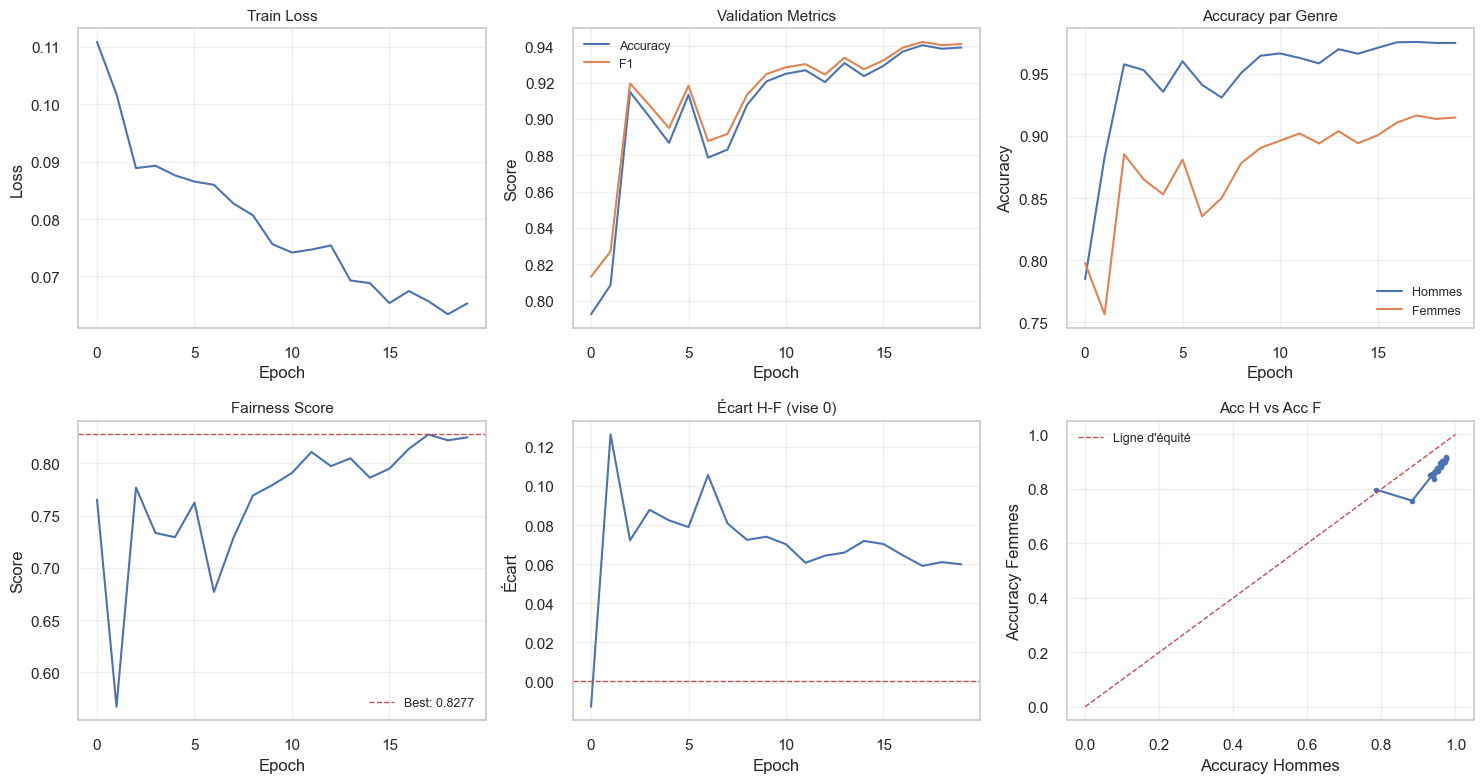

✅ Historique sauvegardé dans reports\training_history.csv


In [16]:
# Visualisation des courbes d'entraînement (optimisée)
try:
    # Vérifier que history existe et n'est pas vide
    if 'history' not in globals() or not history or len(history.get('train_loss', [])) == 0:
        print("⚠️ Aucun historique d'entraînement disponible. Exécutez d'abord la cellule d'entraînement.")
    else:
        # Mode non-interactif pour accélérer
        plt.ioff()
        
        # Créer la figure (taille réduite pour accélérer)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        # Plot 1: Train Loss
        axes[0, 0].plot(history['train_loss'], linewidth=1.5)
        axes[0, 0].set_title('Train Loss', fontsize=11)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: Validation Metrics
        axes[0, 1].plot(history['val_acc'], label='Accuracy', linewidth=1.5)
        axes[0, 1].plot(history['val_f1'], label='F1', linewidth=1.5)
        axes[0, 1].set_title('Validation Metrics', fontsize=11)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].legend(fontsize=9)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: Accuracy par Genre
        axes[0, 2].plot(history['val_acc_h'], label='Hommes', linewidth=1.5)
        axes[0, 2].plot(history['val_acc_f'], label='Femmes', linewidth=1.5)
        axes[0, 2].set_title('Accuracy par Genre', fontsize=11)
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Accuracy')
        axes[0, 2].legend(fontsize=9)
        axes[0, 2].grid(True, alpha=0.3)
        
        # Plot 4: Fairness Score
        axes[1, 0].plot(history['val_fairness'], linewidth=1.5)
        axes[1, 0].set_title('Fairness Score', fontsize=11)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Score')
        if 'best_fairness' in globals():
            axes[1, 0].axhline(y=best_fairness, color='r', linestyle='--', linewidth=1, label=f'Best: {best_fairness:.4f}')
        axes[1, 0].legend(fontsize=9)
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 5: Écart H-F
        if len(history['val_acc_h']) > 0 and len(history['val_acc_f']) > 0:
            ecart = np.array(history['val_acc_h']) - np.array(history['val_acc_f'])
            axes[1, 1].plot(ecart, linewidth=1.5)
            axes[1, 1].set_title('Écart H-F (vise 0)', fontsize=11)
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Écart')
            axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
            axes[1, 1].grid(True, alpha=0.3)
        
        # Plot 6: Acc H vs Acc F
        if len(history['val_acc_h']) > 0 and len(history['val_acc_f']) > 0:
            axes[1, 2].plot(history['val_acc_h'], history['val_acc_f'], marker='o', markersize=4, linewidth=1.5)
            axes[1, 2].set_title('Acc H vs Acc F', fontsize=11)
            axes[1, 2].set_xlabel('Accuracy Hommes')
            axes[1, 2].set_ylabel('Accuracy Femmes')
            axes[1, 2].plot([0, 1], [0, 1], 'r--', linewidth=1, label="Ligne d'équité")
            axes[1, 2].legend(fontsize=9)
            axes[1, 2].grid(True, alpha=0.3)
        
        # Sauvegarder (DPI réduit pour accélérer)
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / "training_curves.png", dpi=100, bbox_inches="tight", facecolor='white')
        print(f"✅ Graphiques sauvegardés dans {REPORTS_DIR / 'training_curves.png'}")
        
        # Afficher (mode rapide)
        plt.show(block=False)
        plt.ion()  # Réactiver le mode interactif
        
        # Sauvegarder l'historique en CSV
        history_df = pd.DataFrame(history)
        history_df.to_csv(REPORTS_DIR / "training_history.csv", index=False)
        print(f"✅ Historique sauvegardé dans {REPORTS_DIR / 'training_history.csv'}")
        
except Exception as e:
    print(f"⚠️ Erreur lors de la visualisation : {e}")
    print("   Vérifiez que l'entraînement a été exécuté et que 'history' existe.")


## 9. Évaluation Finale et Sauvegarde du Modèle


In [17]:
# Rapport final et sauvegarde du modèle
final_metrics = evaluate_model(model, val_loader, device)
print("\n" + "="*70)
print("MÉTRIQUES FINALES")
print("="*70)
print(f"Accuracy globale : {final_metrics['acc_global']:.4f}")
print(f"F1 globale : {final_metrics['f1_global']:.4f}")
print(f"Accuracy Hommes : {final_metrics['acc_h']:.4f}")
print(f"Accuracy Femmes : {final_metrics['acc_f']:.4f}")
print(f"Écart H-F : {abs(final_metrics['acc_h'] - final_metrics['acc_f']):.4f}")
print(f"Fairness Score (S) : {final_metrics['fairness_score']:.4f}")

print("\nClassification Report :")
print(classification_report(
    final_metrics['all_labels'],
    final_metrics['all_preds'],
    target_names=['négatif', 'positif']
))

metrics_dict = {
    'acc_global': float(final_metrics['acc_global']),
    'f1_global': float(final_metrics['f1_global']),
    'acc_h': float(final_metrics['acc_h']),
    'acc_f': float(final_metrics['acc_f']),
    'fairness_score': float(final_metrics['fairness_score']),
    'best_epoch': int(best_epoch)
}

with open(REPORTS_DIR / "final_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=2)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': best_epoch,
    'class_weights': class_weights.tolist(),
    'metrics': metrics_dict
}

model_path = ARTIFACTS_DIR / "model_best.pth"
torch.save(checkpoint, model_path)
print(f"\n✅ Modèle sauvegardé dans {model_path}")
print(f"✅ Métriques sauvegardées dans {REPORTS_DIR / 'final_metrics.json'}")



MÉTRIQUES FINALES
Accuracy globale : 0.9393
F1 globale : 0.9412
Accuracy Hommes : 0.9746
Accuracy Femmes : 0.9147
Écart H-F : 0.0599
Fairness Score (S) : 0.8249

Classification Report :
              precision    recall  f1-score   support

     négatif       0.98      0.94      0.96     14504
     positif       0.79      0.94      0.86      3496

    accuracy                           0.94     18000
   macro avg       0.89      0.94      0.91     18000
weighted avg       0.95      0.94      0.94     18000


✅ Modèle sauvegardé dans artifacts\model_best.pth
✅ Métriques sauvegardées dans reports\final_metrics.json


## 10. Optimisation des Seuils par Groupe (QUESTIONS 6 & 7)

Optimisation des seuils de décision séparés pour hommes et femmes pour maximiser la métrique S


In [27]:
# QUESTION 6 : Optimisation des seuils par groupe
def optimize_thresholds_by_gender(model, loader, device):
    """Optimise les seuils par groupe pour maximiser la métrique S"""
    model.eval()
    all_probs = []
    all_labels = []
    all_genders = []
    
    # Barre de progression pour l'optimisation
    pbar = tqdm(loader, desc='Optimisation seuils', leave=False, unit='batch')
    
    with torch.no_grad():
        for batch in pbar:
            images = batch['image'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            genders = batch['gender'].to(device, non_blocking=True)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_genders.extend(genders.cpu().numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_genders = np.array(all_genders)
    
    best_score = -1
    best_thresh_h = 0.5
    best_thresh_f = 0.5
    
    mask_h = (all_genders == 1)
    mask_f = (all_genders == -1)
    
    # Barre de progression pour la recherche de seuils
    thresh_h_values = np.arange(0.3, 0.8, 0.02)
    thresh_f_values = np.arange(0.3, 0.8, 0.02)
    total_combinations = len(thresh_h_values) * len(thresh_f_values)
    
    print(f"Recherche de seuils optimaux ({total_combinations} combinaisons)...")
    thresh_pbar = tqdm(total=total_combinations, desc='Recherche seuils', unit='comb')
    
    for thresh_h in thresh_h_values:
        for thresh_f in thresh_f_values:
            thresh_pbar.update(1)
            preds_h = (all_probs[mask_h] > thresh_h).astype(int)
            preds_f = (all_probs[mask_f] > thresh_f).astype(int)
            acc_h = accuracy_score(all_labels[mask_h], preds_h) if mask_h.sum() > 0 else 0
            acc_f = accuracy_score(all_labels[mask_f], preds_f) if mask_f.sum() > 0 else 0
            score = compute_fairness_metric(acc_h, acc_f)
            if score > best_score:
                best_score = score
                best_thresh_h = thresh_h
                best_thresh_f = thresh_f
                thresh_pbar.set_postfix({
                    'best_score': f'{best_score:.4f}',
                    'thresh_h': f'{best_thresh_h:.2f}',
                    'thresh_f': f'{best_thresh_f:.2f}'
                })
    
    thresh_pbar.close()
    return best_thresh_h, best_thresh_f, best_score

optimal_thresh_h, optimal_thresh_f, optimal_score = optimize_thresholds_by_gender(model, val_loader, device)
print(f"✅ Seuils optimisés (QUESTION 6 & 7) :")
print(f"   - Seuil hommes : {optimal_thresh_h:.3f}")
print(f"   - Seuil femmes : {optimal_thresh_f:.3f}")
print(f"   - Score équité : {optimal_score:.4f}")


Recherche de seuils optimaux (625 combinaisons)...


Recherche seuils: 100%|██████████| 625/625 [00:00<00:00, 714.86comb/s, best_score=0.1221, thresh_h=0.30, thresh_f=0.78]

✅ Seuils optimisés (QUESTION 6 & 7) :
   - Seuil hommes : 0.300
   - Seuil femmes : 0.780
   - Score équité : 0.1221


### 10.1 Modèle de Détection de Genre (pour utiliser les seuils optimisés en test)

Création d'un modèle léger pour prédire le genre sur les images de test, permettant d'utiliser les seuils optimisés par groupe.


In [28]:
# AMÉLIORATION : Modèle de détection de genre pour utiliser les seuils optimisés en test
print("="*70)
print("ENTRAÎNEMENT MODÈLE DE DÉTECTION DE GENRE")
print("="*70)

# Créer un modèle simple pour la détection de genre (classification binaire)
class GenderClassifier(nn.Module):
    """Modèle léger pour détecter le genre (homme/femme)"""
    def __init__(self, backbone_model):
        super().__init__()
        # Extraire le backbone (features extractor) du modèle principal
        # Pour ConvNeXt, on prend tout sauf le classifier final
        if hasattr(backbone_model, 'stages'):
            # ConvNeXt architecture
            self.backbone = nn.Sequential(
                backbone_model.stem,
                backbone_model.stages[0],
                backbone_model.stages[1],
                backbone_model.stages[2],
                backbone_model.stages[3],
                backbone_model.norm_pre  # Normalization avant classifier
            )
        else:
            # Fallback pour autres architectures
            self.backbone = nn.Sequential(*list(backbone_model.children())[:-1])
        
        # Classifier binaire pour genre
        with torch.no_grad():
            # Obtenir la taille des features en appliquant EXACTEMENT les mêmes
            # opérations que dans self.gender_classifier (pooling global + flatten)
            dummy_input = torch.randn(1, 3, 96, 96).to(device)
            dummy_features = self.backbone(dummy_input)              # [1, C, H, W]
            dummy_features = nn.AdaptiveAvgPool2d(1)(dummy_features) # [1, C, 1, 1]
            dummy_features = torch.flatten(dummy_features, 1)        # [1, C]
            feature_size = dummy_features.size(1)                    # C (ex: 768)
        
        self.gender_classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(feature_size, 2)  # 2 classes : femme (-1) -> 0, homme (1) -> 1
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.gender_classifier(features)

# Créer le modèle de genre en utilisant le backbone du modèle principal
gender_model = GenderClassifier(model).to(device)

# Loss et optimizer pour le modèle de genre
gender_criterion = nn.CrossEntropyLoss()
gender_optimizer = optim.Adam(gender_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Entraînement rapide du modèle de genre (quelques epochs)
print("Entraînement du modèle de genre...")
gender_model.train()
num_epochs_gender = 5

for epoch in range(num_epochs_gender):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs_gender}', leave=False):
        images = batch['image'].to(device, non_blocking=True)
        # Convertir genre : -1 (femme) -> 0, 1 (homme) -> 1
        genders = ((batch['gender'].to(device, non_blocking=True) + 1) // 2).long()
        
        gender_optimizer.zero_grad()
        outputs = gender_model(images)
        loss = gender_criterion(outputs, genders)
        loss.backward()
        gender_optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 2 == 0:
        print(f"  Epoch {epoch+1}: Loss = {avg_loss:.4f}")

# Évaluation sur validation
gender_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device, non_blocking=True)
        genders = ((batch['gender'].to(device, non_blocking=True) + 1) // 2).long()
        outputs = gender_model(images)
        _, predicted = outputs.max(1)
        total += genders.size(0)
        correct += predicted.eq(genders).sum().item()

gender_acc = 100. * correct / total
print(f"✅ Modèle de genre entraîné - Accuracy: {gender_acc:.2f}%")

# Sauvegarder le modèle de genre
gender_model_path = ARTIFACTS_DIR / "gender_model.pth"
torch.save(gender_model.state_dict(), gender_model_path)
print(f"✅ Modèle de genre sauvegardé dans {gender_model_path}")


ENTRAÎNEMENT MODÈLE DE DÉTECTION DE GENRE
Entraînement du modèle de genre...


  Epoch 2: Loss = 0.0793


  Epoch 4: Loss = 0.0663


✅ Modèle de genre entraîné - Accuracy: 97.82%
✅ Modèle de genre sauvegardé dans artifacts\gender_model.pth


## 11. Inférence sur Test Set

Génération des prédictions pour le fichier `test.txt` et création du fichier de soumission


In [30]:
# INFÉRENCE SUR TEST.TXT
print("="*70)
print("INFÉRENCE SUR TEST.TXT")
print("="*70)

def load_test_image(filename):
    test_dir = DATA_DIR / "test"
    if test_dir.exists():
        image_path = test_dir / filename
        if image_path.exists():
            return Image.open(image_path).convert("RGB")
    if TEST_ZIP.exists():
        with ZipFile(TEST_ZIP) as archive:
            for name in archive.namelist():
                if Path(name).name == filename:
                    with archive.open(name) as f:
                        return Image.open(f).convert("RGB")
    raise FileNotFoundError(f"Image test non trouvée: {filename}")

class TestDataset(Dataset):
    def __init__(self, filenames, transform=None):
        self.filenames = filenames.tolist()
        self.transform = transform
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img = load_test_image(filename)
        if self.transform:
            img = self.transform(img)
        return {'image': img, 'filename': filename}

test_df = pd.read_csv(TEST_TXT, header=None, names=["filename"])
print(f"Nombre d'images de test : {len(test_df)}")

test_dataset = TestDataset(test_df["filename"], transform=val_transform)
# num_workers=0 pour éviter les problèmes de pickle avec les classes définies dans le notebook
# Utiliser le même batch_size que pour l'entraînement
try:
    BATCH_SIZE  # Utiliser le batch_size défini précédemment
except NameError:
    BATCH_SIZE = 64  # Valeur par défaut si pas défini

# Pin memory selon le device (CUDA seulement, pas MPS)
test_pin_mem = torch.cuda.is_available() and device.type == 'cuda'
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=test_pin_mem)

# AMÉLIORATION : Test-Time Augmentation (TTA) + Seuils optimisés par genre
print("\n" + "="*70)
print("AMÉLIORATION : Utilisation des seuils optimisés + TTA")
print("="*70)
print(f"   - Seuil hommes : {optimal_thresh_h:.3f}")
print(f"   - Seuil femmes : {optimal_thresh_f:.3f}")
print(f"   - TTA activé : 5 augmentations par image")

# Définir les augmentations pour TTA
tta_transforms = [
    transforms.Compose([transforms.Resize((96, 96)), transforms.ToTensor(), 
                       transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),  # Original
    transforms.Compose([transforms.Resize((96, 96)), transforms.RandomHorizontalFlip(p=1.0), 
                       transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),  # Flip
    transforms.Compose([transforms.Resize((96, 96)), transforms.RandomRotation(5), 
                       transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),  # Rotation +5

    transforms.Compose([transforms.Resize((96, 96)), transforms.RandomRotation((-5, -5)),
                   transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),  # Rotation -5

    transforms.Compose([transforms.Resize((96, 96)), transforms.ColorJitter(brightness=0.1, contrast=0.1), 
                       transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),  # Color jitter
]

model.eval()
gender_model.eval()
all_predictions = []
all_filenames = []

# Barre de progression pour l'inférence
test_pbar = tqdm(test_loader, desc='Inference (TTA+Seuils)', unit='batch')

with torch.no_grad():
    for batch in test_pbar:
        filenames = batch['filename']
        all_filenames.extend(filenames)
        
        # Charger les images originales
        original_images = []
        for filename in filenames:
            img = load_test_image(filename)
            original_images.append(img)
        
        # TTA : Moyenner les prédictions sur plusieurs augmentations
        batch_probs_list = []
        batch_gender_preds = []
        
        for tta_idx, tta_transform in enumerate(tta_transforms):
            # Appliquer la transformation TTA
            tta_images = torch.stack([tta_transform(img) for img in original_images]).to(device, non_blocking=True)
            
            # Prédiction du modèle principal
            outputs = model(tta_images)
            probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            batch_probs_list.append(probs)
            
            # Prédiction du genre (seulement sur la première augmentation pour éviter redondance)
            if tta_idx == 0:
                gender_outputs = gender_model(tta_images)
                gender_probs = F.softmax(gender_outputs, dim=1)
                # Probabilité d'être homme (classe 1)
                gender_preds = (gender_probs[:, 1] > 0.5).cpu().numpy().astype(int)
                batch_gender_preds = gender_preds
        
        # Moyenner les probabilités sur toutes les augmentations TTA
        avg_probs = np.mean(batch_probs_list, axis=0)
        
        # Appliquer les seuils optimisés selon le genre prédit
        preds = np.zeros(len(avg_probs), dtype=int)
        for i, (prob, gender_pred) in enumerate(zip(avg_probs, batch_gender_preds)):
            if gender_pred == 1:  # Homme
                preds[i] = 1 if prob > optimal_thresh_h else 0
            else:  # Femme
                preds[i] = 1 if prob > optimal_thresh_f else 0
        
        # Convertir 0/1 vers -1/1
        preds = preds * 2 - 1
        all_predictions.extend(preds)

print(f"✅ Prédictions générées avec TTA et seuils optimisés : {len(all_predictions)} images")


INFÉRENCE SUR TEST.TXT
Nombre d'images de test : 9999

AMÉLIORATION : Utilisation des seuils optimisés + TTA
   - Seuil hommes : 0.300
   - Seuil femmes : 0.780
   - TTA activé : 5 augmentations par image


Inference (TTA+Seuils): 100%|██████████| 79/79 [09:35<00:00,  7.28s/batch]

✅ Prédictions générées avec TTA et seuils optimisés : 9999 images


### 11.1 Création du fichier de soumission


In [31]:
# Création du fichier de soumission (CRITIQUE)
submission_df = pd.DataFrame({
    'filename': all_filenames,
    'prediction': all_predictions
})

test_df_check = pd.read_csv(TEST_TXT, header=None, names=["filename"])
assert len(submission_df) == len(test_df_check), f"Nombre différent : {len(submission_df)} vs {len(test_df_check)}"
assert submission_df['filename'].tolist() == test_df_check['filename'].tolist(), "Ordre différent !"

submission_path = SUBMISSIONS_DIR / f"predictions_{TEAM_NAME}.txt"
submission_df.to_csv(submission_path, sep="\t", index=False, header=False)

print(f"✅ Fichier de soumission créé : {submission_path}")
print(f"   Nombre de lignes : {len(submission_df)}")
print(f"   Format : filename\\tprediction")
print(f"\nAperçu :")
print(submission_df.head(10))

print("\n" + "="*70)
print("✅ INFÉRENCE TERMINÉE")
print("="*70)


✅ Fichier de soumission créé : submissions\predictions_nom1_nom2.txt
   Nombre de lignes : 9999
   Format : filename\tprediction

Aperçu :
     filename  prediction
0  000000.jpg           1
1  000001.jpg          -1
2  000002.jpg           1
3  000003.jpg           1
4  000004.jpg          -1
5  000005.jpg           1
6  000006.jpg          -1
7  000007.jpg           1
8  000008.jpg          -1
9  000009.jpg           1

✅ INFÉRENCE TERMINÉE
